In [226]:
!pip install scikit-learn

In [227]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer


In [228]:
movies = pd.read_csv('movies.csv') ## Reading the movies.csv file into a DataFrame called 'movies'


In [229]:
ratings = pd.read_csv('ratings.csv') ## Reading the ratings.csv file into a DataFrame called 'ratings'

In [230]:
movies.head() ## Displaying the first few rows of the 'movies' DataFrame to get an overview of its structure and contents


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [231]:
ratings.head() ## Displaying the first few rows of the 'ratings' DataFrame to get an overview of its structure and contents

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [232]:
ratings = ratings.drop('timestamp', axis=1) ## Dropping the 'timestamp' column from the 'ratings' DataFrame as it is not needed for the analysis

In [233]:
ratings.head() ## Displaying the first few rows of the 'ratings' DataFrame to check that the 'timestamp' column has been successfully dropped

,userId,movieId,rating
0,1,17,4.0
1,1,25,1.0
2,1,29,2.0
3,1,30,5.0
4,1,32,5.0


In [234]:
movies.shape ### Displaying the shape of the 'movies' DataFrame to see how many rows and columns it contains

(87585, 3)

In [235]:
ratings.shape ### Displaying the shape of the 'ratings' DataFrame to see how many rows and columns it contains

(32000204, 3)

In [236]:
movies.columns ### Displaying the column names of the 'movies' DataFrame to understand its structure

Index(['movieId', 'title', 'genres'], dtype='str')

In [237]:
ratings.columns ### Displaying the column names of the 'ratings' DataFrame to understand its structure

Index(['userId', 'movieId', 'rating'], dtype='str')

In [238]:
movies.info() ### Displaying the summary of the 'movies' DataFrame, including the number of non-null entries and data types of each column

<class 'pandas.DataFrame'>
RangeIndex: 87585 entries, 0 to 87584
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  87585 non-null  int64
 1   title    87585 non-null  str  
 2   genres   87585 non-null  str  
dtypes: int64(1), str(2)
memory usage: 2.0 MB


In [239]:
ratings.info() ### Displaying the summary of the 'ratings' DataFrame, including the number of non-null entries and data types of each column

<class 'pandas.DataFrame'>
RangeIndex: 32000204 entries, 0 to 32000203
Data columns (total 3 columns):
 #   Column   Dtype  
---  ------   -----  
 0   userId   int64  
 1   movieId  int64  
 2   rating   float64
dtypes: float64(1), int64(2)
memory usage: 732.4 MB


In [240]:
movies.describe() ### Displaying the statistical summary of the 'movies' DataFrame, including count, mean, standard deviation, min, max, and quartiles for numerical columns

,movieId
count,87585.000000
mean,157651.365519
std,79013.402099
min,1.000000
25%,112657.000000
50%,165741.000000
75%,213203.000000
max,292757.000000


In [241]:
ratings.describe() ### Displaying the statistical summary of the 'ratings' DataFrame, including count, mean, standard deviation, min, max, and quartiles for numerical columns

,userId,movieId,rating
count,3.200020e+07,3.200020e+07,3.200020e+07
mean,1.002785e+05,2.931861e+04,3.540396e+00
std,5.794905e+04,5.095816e+04,1.058986e+00
min,1.000000e+00,1.000000e+00,5.000000e-01
25%,5.005300e+04,1.233000e+03,3.000000e+00
50%,1.002970e+05,3.452000e+03,3.500000e+00
75%,1.504510e+05,4.419900e+04,4.000000e+00
max,2.009480e+05,2.927570e+05,5.000000e+00


In [242]:
movies.isnull().sum() ### Checking for missing values in the 'movies' DataFrame by summing the number of null entries in each column

movieId    0
title      0
genres     0
dtype: int64

In [243]:
ratings.isnull().sum() ### Checking for missing values in the 'ratings' DataFrame by summing the number of null entries in each column

userId     0
movieId    0
rating     0
dtype: int64

In [244]:
movies.duplicated().sum() ### Checking for duplicate rows in the 'movies' DataFrame by summing the number of duplicated entries

np.int64(0)

In [245]:
ratings.duplicated().sum() ### Checking for duplicate rows in the 'ratings' DataFrame by summing the number of duplicated entries

np.int64(0)

In [246]:
movies.nunique() ### Displaying the number of unique values in each column of the 'movies' DataFrame to understand the distribution of data

movieId    87585
title      87382
genres      1798
dtype: int64

In [247]:
ratings.nunique() ### Displaying the number of unique values in each column of the 'ratings' DataFrame to understand the distribution of data

userId     200948
movieId     84432
rating         10
dtype: int64

In [248]:
df = pd.merge(movies, ratings, on='movieId') ### Merging the 'movies' and 'ratings' DataFrames on the 'movieId' column to create a combined DataFrame called 'df'

In [249]:
df.head() ### Displaying the first few rows of the merged DataFrame to check its structure and content

,movieId,title,genres,userId,rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,10,2.5
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,11,3.0
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.0
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,19,3.0
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,20,5.0


In [250]:
df.shape ### Displaying the shape of the merged DataFrame to see how many rows and columns it contains


(32000204, 5)

In [251]:
df.info() ### Displaying the summary of the merged DataFrame, including the number of non-null entries and data types of each column

<class 'pandas.DataFrame'>
RangeIndex: 32000204 entries, 0 to 32000203
Data columns (total 5 columns):
 #   Column   Dtype  
---  ------   -----  
 0   movieId  int64  
 1   title    str    
 2   genres   str    
 3   userId   int64  
 4   rating   float64
dtypes: float64(1), int64(2), str(2)
memory usage: 1.2 GB


In [252]:
df.isnull().sum() ### Checking for missing values in the merged DataFrame by summing the number of null entries in each column

movieId    0
title      0
genres     0
userId     0
rating     0
dtype: int64

In [253]:
rating_count = df.groupby('title')['rating'].count().reset_index(name='rating_count').sort_values('rating_count', ascending=False) ### Grouping the merged DataFrame by 'title' and counting the number of ratings for each movie, then resetting the index and sorting the results in descending order based on the count of ratings

In [254]:
rating_count.head() ### Displaying the first few rows of the 'rating_count' DataFrame to see the movies with the highest number of ratings

,title,rating_count
58799,"Shawshank Redemption, The (1994)",102929
25132,Forrest Gump (1994),100296
53404,Pulp Fiction (1994),98409
42977,"Matrix, The (1999)",93808
59415,"Silence of the Lambs, The (1991)",90330


In [255]:
average_rating = df.groupby('title')['rating'].mean().reset_index(name='average_rating').sort_values('average_rating', ascending=False) ### Grouping the merged DataFrame by 'title' and calculating the average rating for each movie, then resetting the index and sorting the results in descending order based on the average rating

In [256]:
average_rating.head() ### Displaying the first few rows of the 'average_rating' DataFrame to see the movies with the highest average ratings

,title,average_rating
12181,CKY 3 (2001),5.0
30918,Hometown Holiday (2018),5.0
30917,Hometown Hero (2017),5.0
30916,Hometown Christmas (2018),5.0
30905,Homemade Christmas (2020),5.0


In [257]:
movies_stats = pd.merge(rating_count, average_rating, on='title') ### Merging the 'rating_count' and 'average_rating' DataFrames on the 'title' column to create a new DataFrame called 'movies_stats' that contains both the count of ratings and the average rating for each movie

In [258]:
movies_stats.head() ### Displaying the first few rows of the 'movies_stats' DataFrame to check its structure and content

,title,rating_count,average_rating
0,"Shawshank Redemption, The (1994)",102929,4.404614
1,Forrest Gump (1994),100296,4.052744
2,Pulp Fiction (1994),98409,4.196969
3,"Matrix, The (1999)",93808,4.156437
4,"Silence of the Lambs, The (1991)",90330,4.148367


In [259]:
movies_stats.sort_values('rating_count', ascending=False).head(10) ### Displaying the top 10 movies with the highest number of ratings by sorting the 'movies_stats' DataFrame in descending order based on the 'rating_count' column and selecting the first 10 rows

,title,rating_count,average_rating
0,"Shawshank Redemption, The (1994)",102929,4.404614
1,Forrest Gump (1994),100296,4.052744
2,Pulp Fiction (1994),98409,4.196969
3,"Matrix, The (1999)",93808,4.156437
4,"Silence of the Lambs, The (1991)",90330,4.148367
5,Star Wars: Episode IV - A New Hope (1977),85010,4.099824
6,Fight Club (1999),77332,4.228780
7,Jurassic Park (1993),75233,3.698623
8,Schindler's List (1993),73849,4.236990
9,"Lord of the Rings: The Fellowship of the Ring,...",73122,4.092134


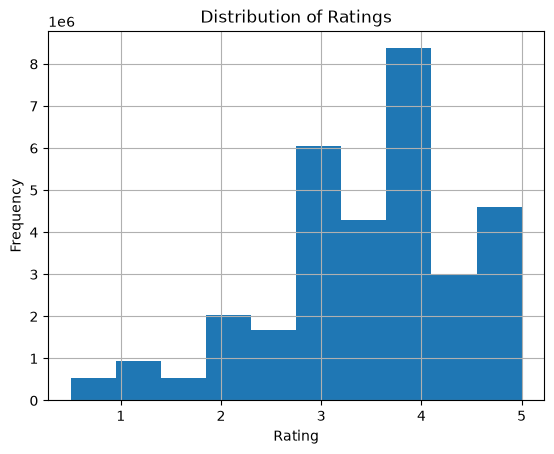

In [260]:
ratings["rating"].hist(bins=10)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show() ### Creating a histogram to visualize the distribution of ratings in the 'ratings' DataFrame, with 10 bins, and adding titles and labels to the axes

In [261]:
ratings["rating"].value_counts().sort_index() ### Counting the occurrences of each unique rating value in the 'ratings' DataFrame, sorting the results by the rating values, and displaying the counts

rating
0.5     525132
1.0     946675
1.5     531063
2.0    2028622
2.5    1685386
3.0    6054990
3.5    4290105
4.0    8367654
4.5    2974000
5.0    4596577
Name: count, dtype: int64

In [262]:
movies_stats.columns ### Displaying the column names of the 'movies_stats' DataFrame to understand its structure

Index(['title', 'rating_count', 'average_rating'], dtype='str')

In [263]:
df = df.merge(movies_stats, on='title') ### Merging the 'df' DataFrame with the 'movies_stats' DataFrame on the 'title' column to include the rating count and average rating for each movie in the main DataFrame

In [264]:
df.columns ### Displaying the column names of the merged DataFrame to understand its structure after merging with 'movies_stats'

Index(['movieId', 'title', 'genres', 'userId', 'rating', 'rating_count',
       'average_rating'],
      dtype='str')

In [265]:
df.head()

,movieId,title,genres,userId,rating,rating_count,average_rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,10,2.5,68997,3.897438
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,11,3.0,68997,3.897438
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.0,68997,3.897438
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,19,3.0,68997,3.897438
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,20,5.0,68997,3.897438


In [266]:
movies['genres_list'] = movies['genres'].str.split('|') ### Splitting the 'genres' column in the 'movies' DataFrame into a list of genres for each movie and storing it in a new column called 'genres_list'

In [267]:
movies[['genres', 'genres_list']].head() ### Displaying the first few rows of the 'movies' DataFrame to show both the original 'genres' column and the new 'genres_list' column, allowing for a comparison of the two representations of genres

,genres,genres_list
0,Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]"
1,Adventure|Children|Fantasy,"[Adventure, Children, Fantasy]"
2,Comedy|Romance,"[Comedy, Romance]"
3,Comedy|Drama|Romance,"[Comedy, Drama, Romance]"
4,Comedy,[Comedy]


In [268]:
movies['genres_list'].dtype ### Checking the data type of the 'genres_list' column in the 'movies' DataFrame to confirm that it is a list

dtype('O')

In [269]:
type(movies['genres_list'].iloc[0]) ### Checking the data type of the first element in the 'genres_list' column to confirm that it is a list

list

In [270]:
movies['genres_list'].apply(len).describe() ### Calculating the length of each list in the 'genres_list' column, applying the 'len' function to each element, and then displaying the statistical summary of these lengths to understand the distribution of the number of genres per movie

count    87585.000000
mean         1.760233
std          0.943453
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         10.000000
Name: genres_list, dtype: float64

In [271]:
movies['genres'].value_counts().get('(no genres listed)', 0) ### Counting the occurrences of the '(no genres listed)' entry in the 'genres' column of the 'movies' DataFrame to determine how many movies do not have any genres specified

np.int64(7080)

In [272]:
movies_with_genres = movies[movies['genres'] != '(no genres listed)'] ### Creating a new DataFrame called 'movies_with_genres' that contains only the movies that have at least one genre listed by filtering out the rows where the 'genres' column is equal to '(no genres listed)'


In [273]:
df[df['title'].isin(movies[movies['genres']=='(no genres listed)']['title'])]['title'].value_counts().head(10) ### Counting the occurrences of each movie title in the merged DataFrame 'df' that corresponds to movies with '(no genres listed)' in the 'movies' DataFrame, and displaying the top 10 most frequently occurring titles

title
Hereditary (2018)                                          4596
Whiplash (2013)                                            3080
Pirates of the Caribbean: Dead Men Tell No Tales (2017)    3064
Fantastic Beasts and Where to Find Them 2 (2018)           2254
Green Room (2015)                                          2148
Eighth Grade (2018)                                        1614
Paterson                                                   1148
Black Mirror                                               1027
Spectral (2016)                                             658
Pitch Perfect 3 (2017)                                      649
Name: count, dtype: int64

In [274]:
genre_fixes = {
    'Hereditary (2018)': 'Drama|Horror|Mystery',
    'Whiplash (2013)': 'Drama|Music',
    'Pirates of the Caribbean: Dead Men Tell No Tales (2017)': 'Action|Adventure|Fantasy',
    'Green Room (2015)': 'Horror|Thriller',
    'Eighth Grade (2018)': 'Comedy|Drama',
} ### Creating a dictionary called 'genre_fixes' that maps specific movie titles to their corrected genre strings, which will be used to update the 'genres' column in the 'movies' DataFrame for these movies


In [275]:
for title, genres in genre_fixes.items():
    movies.loc[movies['title'] == title, 'genres'] = genres ### Iterating over the 'genre_fixes' dictionary and updating the 'genres' column in the 'movies' DataFrame for each specified movie title with the corresponding corrected genre string

In [276]:
total_ratings_missing_genre = df[df['genres'] == '(no genres listed)'].shape[0]
total_ratings = df.shape[0]
print(f"{total_ratings_missing_genre / total_ratings:.2%}") ### Calculating the proportion of ratings in the merged DataFrame 'df' that correspond to movies with '(no genres listed)' in the 'genres' column, and printing this proportion as a percentage

0.17%


In [277]:
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(movies['genres_list'])
genre_df = pd.DataFrame(genre_matrix, columns=mlb.classes_, index=movies['movieId']) ### Using the MultiLabelBinarizer from scikit-learn to transform the 'genres_list' column in the 'movies' DataFrame into a binary matrix, where each genre is represented as a separate column with 1s and 0s indicating the presence or absence of that genre for each movie. The resulting binary matrix is then converted into a DataFrame called 'genre_df', with columns named after the genres and indexed by 'movieId'.

In [278]:
genre_df.head() ### Displaying the first few rows of the 'genre_df' DataFrame to check its structure and content, showing the binary representation of genres for each movie

,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movieId,,,,,,,,,,,,,,,,,,,,
1,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
5,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
